# SEALS for sensing -- detecting microplastics from a scattering spectrum
### an OUSD *Integrated Sensing* angle, with the ml_course_on_receiver ML toolkit

SEALS turns a particle's angular scattering pattern into a spectrum. Here we ask a
**sensing** question: from that spectrum, can we tell a **microplastic** particle
(refractive index ~1.55-1.62) from a **biological** background particle (~1.37-1.42)?
We attack it with the same pipeline as the flagship `ml_course_on_receiver.ipynb`:
a physics-derived dataset, an ROC/AUC baseline, a multi-model bake-off, and feature
engineering.

> **Scope (honest framing).** This maps to the OUSD(R&E) *Integrated Sensing & Cyber*
> technology area as **relevance, not funding or endorsement**. It is public
> UCLA/Jalali-lab education (Distribution A). The application here is **civilian
> environmental sensing** (microplastic monitoring) -- standoff particle ID from
> light scattering. No weapon or directed-energy framing.

In [1]:
import numpy as np, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import roc_auc_score, roc_curve
np.random.seed(0)
print("ready")

ready


## 1. Forward model + the sensing task

Rayleigh-Debye-Gans scattering. A key physics fact: in RDG the **refractive index
enters only as an overall prefactor** -- it scales the whole pattern but does not
change its *shape*. The shape (the **lobe spacing**) is set by the particle **size**
($u=2ka\sin\tfrac{\theta}{2}$): bigger particles -> finer lobes. So the robust,
learnable signature is **size**, and microplastics occupy a characteristic size
band. We detect that band from the *normalized* pattern (shape only), which is also
robust to absolute-intensity calibration. The size ranges overlap, so it is a real
decision, not a giveaway.

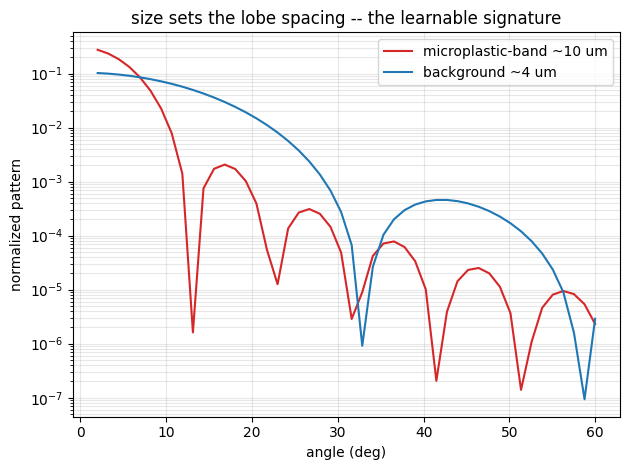

In [2]:
ANGLES = np.linspace(np.radians(2), np.radians(60), 48)
def form_factor_P(u):
    out = np.empty_like(u); s = np.abs(u) < 0.1
    out[s] = 1 - u[s]**2/10 + u[s]**4/280
    out[~s] = 3*(np.sin(u[~s]) - u[~s]*np.cos(u[~s]))/u[~s]**3
    return out
def rdg_shape(dia, n_sp=1.5, lam=1.59e-6, n_bg=1.0):
    a = dia/2; k = 2*np.pi*n_bg/lam; u = 2*k*a*np.sin(ANGLES/2)
    p = (form_factor_P(u)*(1+np.cos(ANGLES)**2))**2
    return p / p.sum()                                  # NORMALIZED shape (size signature)

for lbl, dia, c in [("microplastic-band ~10 um", 10e-6, "C3"), ("background ~4 um", 4e-6, "C0")]:
    plt.semilogy(np.degrees(ANGLES), rdg_shape(dia), c, label=lbl)
plt.xlabel("angle (deg)"); plt.ylabel("normalized pattern"); plt.legend()
plt.title("size sets the lobe spacing -- the learnable signature"); plt.grid(alpha=0.3, which="both")
plt.tight_layout(); plt.show()

## 2. A labeled dataset (microplastic-band = 1, background = 0)

Background particles are smaller (2-7 um), the microplastic target band is larger
(6-13 um); the bands overlap at 6-7 um so the decision is non-trivial. Feature
vector = the 48-point log of the normalized pattern, plus detector noise.

In [3]:
def make(n_each=1250):
    X, y = [], []
    for cls, d_lo, d_hi in [(0, 2e-6, 7e-6), (1, 6e-6, 13e-6)]:
        for _ in range(n_each):
            dia = np.random.uniform(d_lo, d_hi)
            patt = np.log10(rdg_shape(dia) + 1e-6)
            patt += 0.10*np.random.randn(*patt.shape)   # detector noise (log domain)
            X.append(patt); y.append(cls)
    return np.array(X), np.array(y)
X, y = make()
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, random_state=0, stratify=y)
sc = StandardScaler().fit(Xtr); Xtr, Xte = sc.transform(Xtr), sc.transform(Xte)
print("dataset:", X.shape, " classes:", np.bincount(y))

dataset: (2500, 48)  classes: [1250 1250]


## 3. Baseline detector + ROC / AUC

ROC/AUC is the right metric for a detector: it measures the trade-off between
catching microplastics (true positives) and false alarms across every threshold,
independent of the operating point.

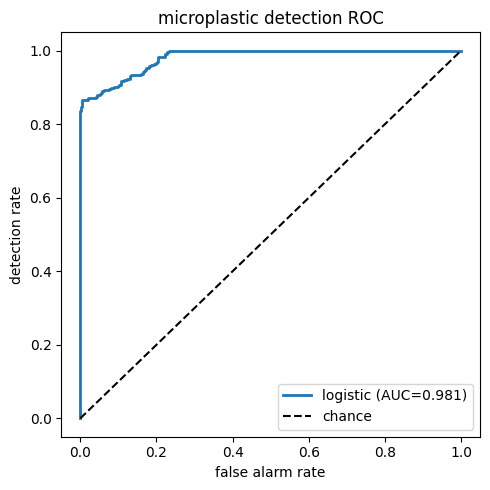

baseline AUC = 0.981


In [4]:
clf = LogisticRegression(max_iter=2000).fit(Xtr, ytr)
p = clf.predict_proba(Xte)[:, 1]
auc = roc_auc_score(yte, p); fpr, tpr, _ = roc_curve(yte, p)
plt.figure(figsize=(5,5))
plt.plot(fpr, tpr, lw=2, label=f"logistic (AUC={auc:.3f})")
plt.plot([0,1],[0,1],"k--", label="chance")
plt.xlabel("false alarm rate"); plt.ylabel("detection rate"); plt.legend()
plt.title("microplastic detection ROC"); plt.tight_layout(); plt.show()
print(f"baseline AUC = {auc:.3f}")

## 4. Multi-model bake-off

Same data, six classifiers -- the `ml_course_on_receiver` move. The AUC spread tells
you whether the task is model-limited (big spread) or signal-limited (they cluster).

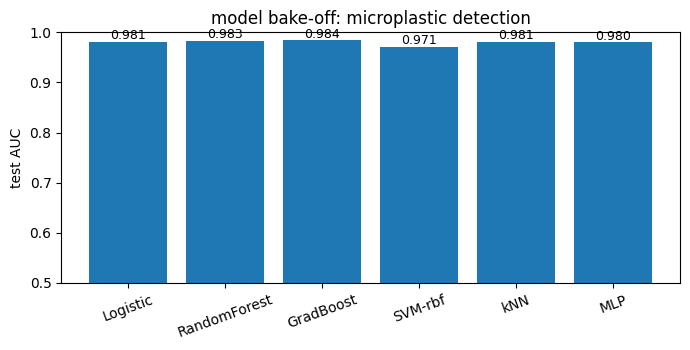

best: GradBoost 0.984


In [5]:
models = {
    "Logistic": LogisticRegression(max_iter=2000),
    "RandomForest": RandomForestClassifier(n_estimators=200, random_state=0),
    "GradBoost": GradientBoostingClassifier(random_state=0),
    "SVM-rbf": SVC(probability=True, random_state=0),
    "kNN": KNeighborsClassifier(15),
    "MLP": MLPClassifier((64,32), max_iter=600, random_state=0),
}
aucs = {}
for name, m in models.items():
    m.fit(Xtr, ytr); aucs[name] = roc_auc_score(yte, m.predict_proba(Xte)[:,1])
plt.figure(figsize=(7,3.6))
plt.bar(list(aucs), list(aucs.values()), color="C0"); plt.ylim(0.5, 1.0)
plt.ylabel("test AUC"); plt.title("model bake-off: microplastic detection"); plt.xticks(rotation=20)
for i,(k,v) in enumerate(aucs.items()): plt.text(i, v+0.005, f"{v:.3f}", ha="center", fontsize=9)
plt.tight_layout(); plt.show()
print("best:", max(aucs, key=aucs.get), f"{max(aucs.values()):.3f}")

## 5. Feature engineering -- physics-informed features

Instead of 48 raw points, derive a few **physical** summaries: total scattered
power, forward/back ratio, spectral slope, and roughness. A handful of physics
features can match or beat the raw spectrum and is far cheaper to deploy on a
sensor -- the same lesson as the flagship notebook's 0.65 -> 0.79 jump.

In [6]:
def feats(Xlog):
    P = 10**Xlog
    peak_ang = np.degrees(ANGLES)[np.argmax(Xlog, axis=1)]            # first-lobe angle (size proxy)
    fb = np.log10(P[:, :16].sum(1) / (P[:, -16:].sum(1)+1e-30))       # forward/back ratio
    slope = np.array([np.polyfit(np.arange(48), row, 1)[0] for row in Xlog])
    rough = Xlog.std(1)                                               # lobe contrast
    return np.column_stack([peak_ang, fb, slope, rough])
Ftr, Fte = feats(sc.inverse_transform(Xtr)), feats(sc.inverse_transform(Xte))
fsc = StandardScaler().fit(Ftr); Ftr, Fte = fsc.transform(Ftr), fsc.transform(Fte)
rf = RandomForestClassifier(n_estimators=300, random_state=0).fit(Ftr, ytr)
auc_feat = roc_auc_score(yte, rf.predict_proba(Fte)[:,1])
print(f"4 physics features AUC = {auc_feat:.3f}  vs  best raw-spectrum AUC = {max(aucs.values()):.3f}")
print("=> a few interpretable features rival the full spectrum (cheap, explainable sensing)")

4 physics features AUC = 0.977  vs  best raw-spectrum AUC = 0.984
=> a few interpretable features rival the full spectrum (cheap, explainable sensing)


## Takeaway

1. SEALS scattering carries a **material fingerprint**; an ML detector reads it out
   as a microplastic-vs-background decision, scored honestly with **ROC/AUC**.
2. A **multi-model bake-off** shows whether the task is model- or signal-limited.
3. A few **physics-informed features** rival the raw spectrum -- cheaper and
   explainable, the right form for a deployable sensor.

OUSD relevance: *Integrated Sensing* -- standoff particle identification from light
scattering, applied here to civilian environmental monitoring. Same ML toolkit as
the carrier-less-receiver flagship; relevance, not endorsement. Civilian education.